<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Quantum_Double_Slit_Experiment_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
!pip install qutip ssqueezepy matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.7/127.7 kB 6.6 MB/s eta 0:00:00


In [2]:
# openEMS Colab installer.

import os
import shutil
import subprocess
import sys
import textwrap
from pathlib import Path


# =============================================================================
# CONTROL KNOBS
# =============================================================================

INSTALL_APT_PACKAGES = True
PYTHON_BRIDGE_REQUIRED = False
OCTAVE_BRIDGE_REQUIRED = False
RUN_APT_UPDATE = True

LOG_DIR = Path("/content/openems_install_logs")
BRIDGE_MODULE_PATH = Path("/content/openems_colab_bridge.py")
SMOKE_TEST_DIR = Path("/content/openems_smoke_tests")

APT_PACKAGES = (
    "openems",
    "python3-openems",
    "libopenems-dev",
    "octave-openems",
    "octave",
    "python3-numpy",
    "python3-h5py",
    "python3-matplotlib",
    "python3-scipy",
)

PYTHON_CANDIDATES = (
    "/usr/bin/python3",
    "/usr/bin/python3.10",
    "/usr/bin/python3.11",
)


# =============================================================================
# COMMAND HELPERS
# =============================================================================

def run_command(
    command: list[str],
    *,
    check: bool = True,
    env: dict[str, str] | None = None,
    cwd: Path | None = None,
    log_name: str | None = None,
) -> subprocess.CompletedProcess[str]:
    """Run a command, print its tail, and optionally save a log."""
    LOG_DIR.mkdir(parents=True, exist_ok=True)
    print("$ " + " ".join(command))

    result = subprocess.run(
        command,
        check=False,
        cwd=str(cwd) if cwd is not None else None,
        env=env,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )

    output = result.stdout or ""
    if log_name is not None:
        path = LOG_DIR / log_name
        path.write_text(output, encoding="utf-8", errors="replace")
        print(f"log written to {path}")

    if output:
        print(output[-5000:])

    if check and result.returncode != 0:
        raise RuntimeError(
            f"Command failed with code {result.returncode}: "
            + " ".join(command)
        )

    return result


def command_exists(command_name: str) -> bool:
    """Return True when a command exists on PATH."""
    return shutil.which(command_name) is not None


def apt_candidate_exists(package_name: str) -> bool:
    """Return True when apt can install a package."""
    if not command_exists("apt-cache"):
        return False

    result = run_command(
        ["apt-cache", "policy", package_name],
        check=False,
        log_name=f"apt_policy_{package_name}.log",
    )
    text = result.stdout or ""
    return "Candidate:" in text and "Candidate: (none)" not in text


def apt_install_available(packages: tuple[str, ...]) -> None:
    """Install packages available from the current Colab apt repositories."""
    if RUN_APT_UPDATE:
        run_command(
            ["apt-get", "update", "-qq"],
            check=False,
            log_name="apt_update.log",
        )

    available = tuple(pkg for pkg in packages if apt_candidate_exists(pkg))
    skipped = tuple(pkg for pkg in packages if pkg not in available)

    if skipped:
        print("Skipped unavailable apt packages:")
        for package_name in skipped:
            print(f"  {package_name}")

    if not available:
        raise RuntimeError("No requested apt packages were available.")

    run_command(
        ["apt-get", "install", "-y", "-qq", *available],
        check=True,
        log_name="apt_install_openems.log",
    )


# =============================================================================
# ENVIRONMENTS AND DIAGNOSTICS
# =============================================================================

def clean_system_env() -> dict[str, str]:
    """Return a minimal environment for apt-provided Python bindings."""
    return {
        "HOME": os.environ.get("HOME", "/root"),
        "LANG": os.environ.get("LANG", "C.UTF-8"),
        "LC_ALL": os.environ.get("LC_ALL", "C.UTF-8"),
        "PATH": "/usr/bin:/bin:/usr/sbin:/sbin",
        "PYTHONNOUSERSITE": "1",
        "PYTHONPATH": "/usr/lib/python3/dist-packages",
    }


def openems_binaries_available() -> bool:
    """Return True when command-line openEMS executables are available."""
    ok = True
    for name in ("openEMS", "AppCSXCAD"):
        path = shutil.which(name)
        if path is None:
            print(f"Missing executable: {name}")
            ok = False
        else:
            print(f"Found executable: {name} -> {path}")
    return ok


def print_package_locations() -> None:
    """Print installed openEMS package locations for debugging."""
    for package_name in ("python3-openems", "openems", "octave-openems"):
        result = run_command(
            ["dpkg", "-L", package_name],
            check=False,
            env=clean_system_env(),
            log_name=f"dpkg_L_{package_name}.log",
        )
        if result.returncode == 0:
            interesting = [
                line
                for line in (result.stdout or "").splitlines()
                if (
                    "dist-packages" in line
                    or "/usr/share/openEMS" in line
                    or "/usr/share/CSXCAD" in line
                )
            ]
            print(f"Key files from {package_name}:")
            for line in interesting[:80]:
                print("  " + line)


# =============================================================================
# PYTHON AND OCTAVE PROBES
# =============================================================================

def python_probe_code() -> str:
    """Return the Python probe used to verify openEMS bindings."""
    return r'''
import importlib.util
import sys

print("python executable:", sys.executable)
print("python version:", sys.version.replace("\\n", " "))
print("sys.path:")
for item in sys.path:
    print("  " + str(item))

for module_name in ("CSXCAD", "openEMS"):
    spec = importlib.util.find_spec(module_name)
    print(f"spec {module_name}: {spec}")
    if spec is not None:
        print(f"origin {module_name}: {spec.origin}")
        print(f"locations {module_name}: {spec.submodule_search_locations}")

from CSXCAD import ContinuousStructure
from openEMS import openEMS

csx = ContinuousStructure()
fdtd = openEMS()

print("ContinuousStructure:", type(csx))
print("openEMS:", type(fdtd))
print("OPENEMS_PYTHON_BINDINGS_OK")
'''


def test_python_candidate(python_executable: str) -> bool:
    """Return True when one Python executable can import openEMS bindings."""
    if not Path(python_executable).exists():
        return False

    safe_name = Path(python_executable).name.replace(".", "_")
    result = run_command(
        [python_executable, "-c", python_probe_code()],
        check=False,
        env=clean_system_env(),
        log_name=f"probe_openems_{safe_name}.log",
    )
    return (
        result.returncode == 0
        and "OPENEMS_PYTHON_BINDINGS_OK" in (result.stdout or "")
    )


def select_openems_python() -> str | None:
    """Return a Python executable that can import openEMS, if one exists."""
    candidates = []
    candidates.extend(PYTHON_CANDIDATES)
    candidates.append(sys.executable)

    seen: set[str] = set()
    for candidate in candidates:
        path = shutil.which(candidate) if "/" not in candidate else candidate
        if path is None or path in seen:
            continue
        seen.add(path)
        print(f"Testing openEMS Python candidate: {path}")
        if test_python_candidate(path):
            print(f"Selected openEMS Python executable: {path}")
            return path

    return None


def octave_probe_code() -> str:
    """Return an Octave probe for the openEMS interface."""
    return """
addpath('/usr/share/openEMS/matlab');
addpath('/usr/share/CSXCAD/matlab');
disp('Octave path configured for openEMS');
which openEMS
which InitFDTD
which WriteOpenEMS
disp('OPENEMS_OCTAVE_INTERFACE_OK');
"""


def test_octave_interface() -> bool:
    """Return True when the Octave openEMS interface is available."""
    if not shutil.which("octave"):
        print("Octave executable is unavailable.")
        return False

    SMOKE_TEST_DIR.mkdir(parents=True, exist_ok=True)
    script_path = SMOKE_TEST_DIR / "openems_octave_probe.m"
    script_path.write_text(octave_probe_code(), encoding="utf-8")

    result = run_command(
        ["octave", "--quiet", str(script_path)],
        check=False,
        env=clean_system_env(),
        log_name="probe_openems_octave.log",
    )
    return (
        result.returncode == 0
        and "OPENEMS_OCTAVE_INTERFACE_OK" in (result.stdout or "")
    )


# =============================================================================
# BRIDGE MODULE WRITER
# =============================================================================

def write_bridge_module(
    python_executable: str | None,
    octave_available: bool,
) -> None:
    """Write a Colab bridge module without nested-string syntax hazards."""
    python_literal = repr(python_executable) if python_executable else "None"
    octave_literal = "True" if octave_available else "False"

    bridge_code = f'''
from __future__ import annotations

import os
import subprocess
import textwrap
from pathlib import Path
from typing import Mapping


OPENEMS_PYTHON = {python_literal}
OCTAVE_AVAILABLE = {octave_literal}
DEFAULT_WORK_DIR = Path("/content/openems_runs")


def _base_env(extra_env: Mapping[str, str] | None = None) -> dict[str, str]:
    env = {{
        "HOME": os.environ.get("HOME", "/root"),
        "LANG": os.environ.get("LANG", "C.UTF-8"),
        "LC_ALL": os.environ.get("LC_ALL", "C.UTF-8"),
        "PATH": "/usr/bin:/bin:/usr/sbin:/sbin",
        "PYTHONNOUSERSITE": "1",
        "PYTHONPATH": "/usr/lib/python3/dist-packages",
    }}
    if extra_env:
        env.update({{str(key): str(value) for key, value in extra_env.items()}})
    return env


def run_openems_binary(
    xml_path: str | Path,
    *,
    work_dir: str | Path | None = None,
    check: bool = True,
) -> subprocess.CompletedProcess[str]:
    path = Path(xml_path)
    cwd = Path(work_dir) if work_dir is not None else path.parent
    result = subprocess.run(
        ["/usr/bin/openEMS", str(path)],
        cwd=str(cwd),
        env=_base_env(),
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        check=False,
    )
    print(result.stdout)
    if check and result.returncode != 0:
        raise subprocess.CalledProcessError(
            result.returncode,
            result.args,
            output=result.stdout,
        )
    return result


def run_openems_python_script(
    script_path: str | Path,
    *,
    work_dir: str | Path | None = None,
    extra_env: Mapping[str, str] | None = None,
    check: bool = True,
) -> subprocess.CompletedProcess[str]:
    if OPENEMS_PYTHON is None:
        raise RuntimeError(
            "No compatible openEMS Python binding was found. "
            "Use run_openems_octave_code() or run_openems_binary()."
        )

    path = Path(script_path)
    cwd = Path(work_dir) if work_dir is not None else path.parent
    cwd.mkdir(parents=True, exist_ok=True)

    result = subprocess.run(
        [OPENEMS_PYTHON, str(path)],
        cwd=str(cwd),
        env=_base_env(extra_env),
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        check=False,
    )
    print(result.stdout)
    if check and result.returncode != 0:
        raise subprocess.CalledProcessError(
            result.returncode,
            result.args,
            output=result.stdout,
        )
    return result


def run_openems_python_code(
    code: str,
    *,
    work_dir: str | Path = DEFAULT_WORK_DIR,
    filename: str = "openems_case.py",
    extra_env: Mapping[str, str] | None = None,
    check: bool = True,
) -> subprocess.CompletedProcess[str]:
    cwd = Path(work_dir)
    cwd.mkdir(parents=True, exist_ok=True)
    script_path = cwd / filename
    script_path.write_text(
        textwrap.dedent(code).strip() + "\\n",
        encoding="utf-8",
    )
    return run_openems_python_script(
        script_path,
        work_dir=cwd,
        extra_env=extra_env,
        check=check,
    )


def run_openems_octave_code(
    code: str,
    *,
    work_dir: str | Path = DEFAULT_WORK_DIR,
    filename: str = "openems_case.m",
    check: bool = True,
) -> subprocess.CompletedProcess[str]:
    if not OCTAVE_AVAILABLE:
        raise RuntimeError("The Octave openEMS interface was unavailable.")

    cwd = Path(work_dir)
    cwd.mkdir(parents=True, exist_ok=True)
    script_path = cwd / filename
    prefix = """
addpath('/usr/share/openEMS/matlab');
addpath('/usr/share/CSXCAD/matlab');
"""
    script_path.write_text(
        textwrap.dedent(prefix + "\\n" + code).strip() + "\\n",
        encoding="utf-8",
    )

    result = subprocess.run(
        ["/usr/bin/octave", "--quiet", str(script_path)],
        cwd=str(cwd),
        env=_base_env(),
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        check=False,
    )
    print(result.stdout)
    if check and result.returncode != 0:
        raise subprocess.CalledProcessError(
            result.returncode,
            result.args,
            output=result.stdout,
        )
    return result
'''
    BRIDGE_MODULE_PATH.write_text(
        textwrap.dedent(bridge_code).strip() + "\n",
        encoding="utf-8",
    )
    print(f"Wrote bridge module: {BRIDGE_MODULE_PATH}")


# =============================================================================
# MAIN
# =============================================================================

def main() -> None:
    """Install openEMS and write a robust Colab bridge."""
    print("openEMS Colab installer")
    print(f"Notebook Python: {sys.executable}")
    print(f"Log directory:   {LOG_DIR}")

    if INSTALL_APT_PACKAGES:
        apt_install_available(APT_PACKAGES)

    binaries_ok = openems_binaries_available()
    if not binaries_ok:
        raise RuntimeError("openEMS command-line binaries were unavailable.")

    print_package_locations()

    openems_python = select_openems_python()
    octave_ok = test_octave_interface()

    if PYTHON_BRIDGE_REQUIRED and openems_python is None:
        raise RuntimeError(
            "A compatible Python binding was not found. "
            f"See logs in {LOG_DIR}."
        )

    if OCTAVE_BRIDGE_REQUIRED and not octave_ok:
        raise RuntimeError(
            "The Octave openEMS interface was not found. "
            f"See logs in {LOG_DIR}."
        )

    write_bridge_module(openems_python, octave_ok)

    print("\nInstallation summary")
    print(f"  openEMS binaries:      {binaries_ok}")
    print(f"  Python binding bridge: {openems_python}")
    print(f"  Octave bridge:         {octave_ok}")

    print("\nUse this in later Colab cells:")
    print(
        "import sys\n"
        "sys.path.insert(0, '/content')\n"
        "from openems_colab_bridge import (\n"
        "    run_openems_binary,\n"
        "    run_openems_octave_code,\n"
        "    run_openems_python_code,\n"
        ")\n"
    )

    if openems_python is not None:
        print(
            "run_openems_python_code(\"\"\"\n"
            "from CSXCAD import ContinuousStructure\n"
            "from openEMS import openEMS\n"
            "print('openEMS Python bridge works')\n"
            "\"\"\")\n"
        )
    elif octave_ok:
        print(
            "run_openems_octave_code(\"\"\"\n"
            "disp('openEMS Octave bridge works');\n"
            "which openEMS\n"
            "\"\"\")\n"
        )
    else:
        print(
            "# Python and Octave interfaces were unavailable, but the openEMS "
            "binary can still run XML files:\n"
            "# run_openems_binary('/content/path/to/simulation.xml')\n"
        )

main()

openEMS Colab installer
Notebook Python: /usr/bin/python3
Log directory:   /content/openems_install_logs
$ apt-get update -qq
log written to /content/openems_install_logs/apt_update.log
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)

$ apt-cache policy openems
log written to /content/openems_install_logs/apt_policy_openems.log
openems:
  Installed: (none)
  Candidate: 0.0.35+git20190103.6a75e98+dfsg.1-3.1build1
  Version table:
     0.0.35+git20190103.6a75e98+dfsg.1-3.1build1 500
        500 http://archive.ubuntu.com/ubuntu jammy/universe amd64 Packages

$ apt-cache policy python3-openems
log written to /content/openems_install_logs/apt_policy_python3-openems.log
python3-openems:
  Installed: (none)
  Candidate: 0.0.35+git20190103.6a75e98+dfsg.1-3.1build1
  Version table:
     0.0.35+git20190103.6a75e98+dfsg.1-3.1build1 500
        500 http://arc

 ---------------------------------------------------------------------- 
 | openEMS 64bit -- version v0.0.35
 | (C) 2010-2018 Thorsten Liebig <thorsten.liebig@gmx.de>  GPL license
 ---------------------------------------------------------------------- 
	Used external libraries:
		CSXCAD -- Version: v0.6.2
		hdf5   -- Version: 1.10.7
		          compiled against: HDF5 library version: 1.10.7
		tinyxml -- compiled against: 2.6.2
		fparser
		boost  -- compiled against: 1_74
		vtk -- Version: 7.1.1
		       compiled against: 7.1.1

Create FDTD operator (compressed SSE + multi-threading)
FDTD simulation size: 325x304x3 --> 296400 FDTD cells 
FDTD timestep is: 3.34366e-17 s; Nyquist rate: 33 timesteps @4.53142e+14 Hz
Excitation signal length is: 1787 timesteps (5.97511e-14s)
Max. number of timesteps: 5500 ( --> 3.07778 * Excitation signal length)
Create FDTD engine (compressed SSE + multi-threading)
Running FDTD engine... this may take a while... grab a cup of coffee?!?
[@        4s] Timeste

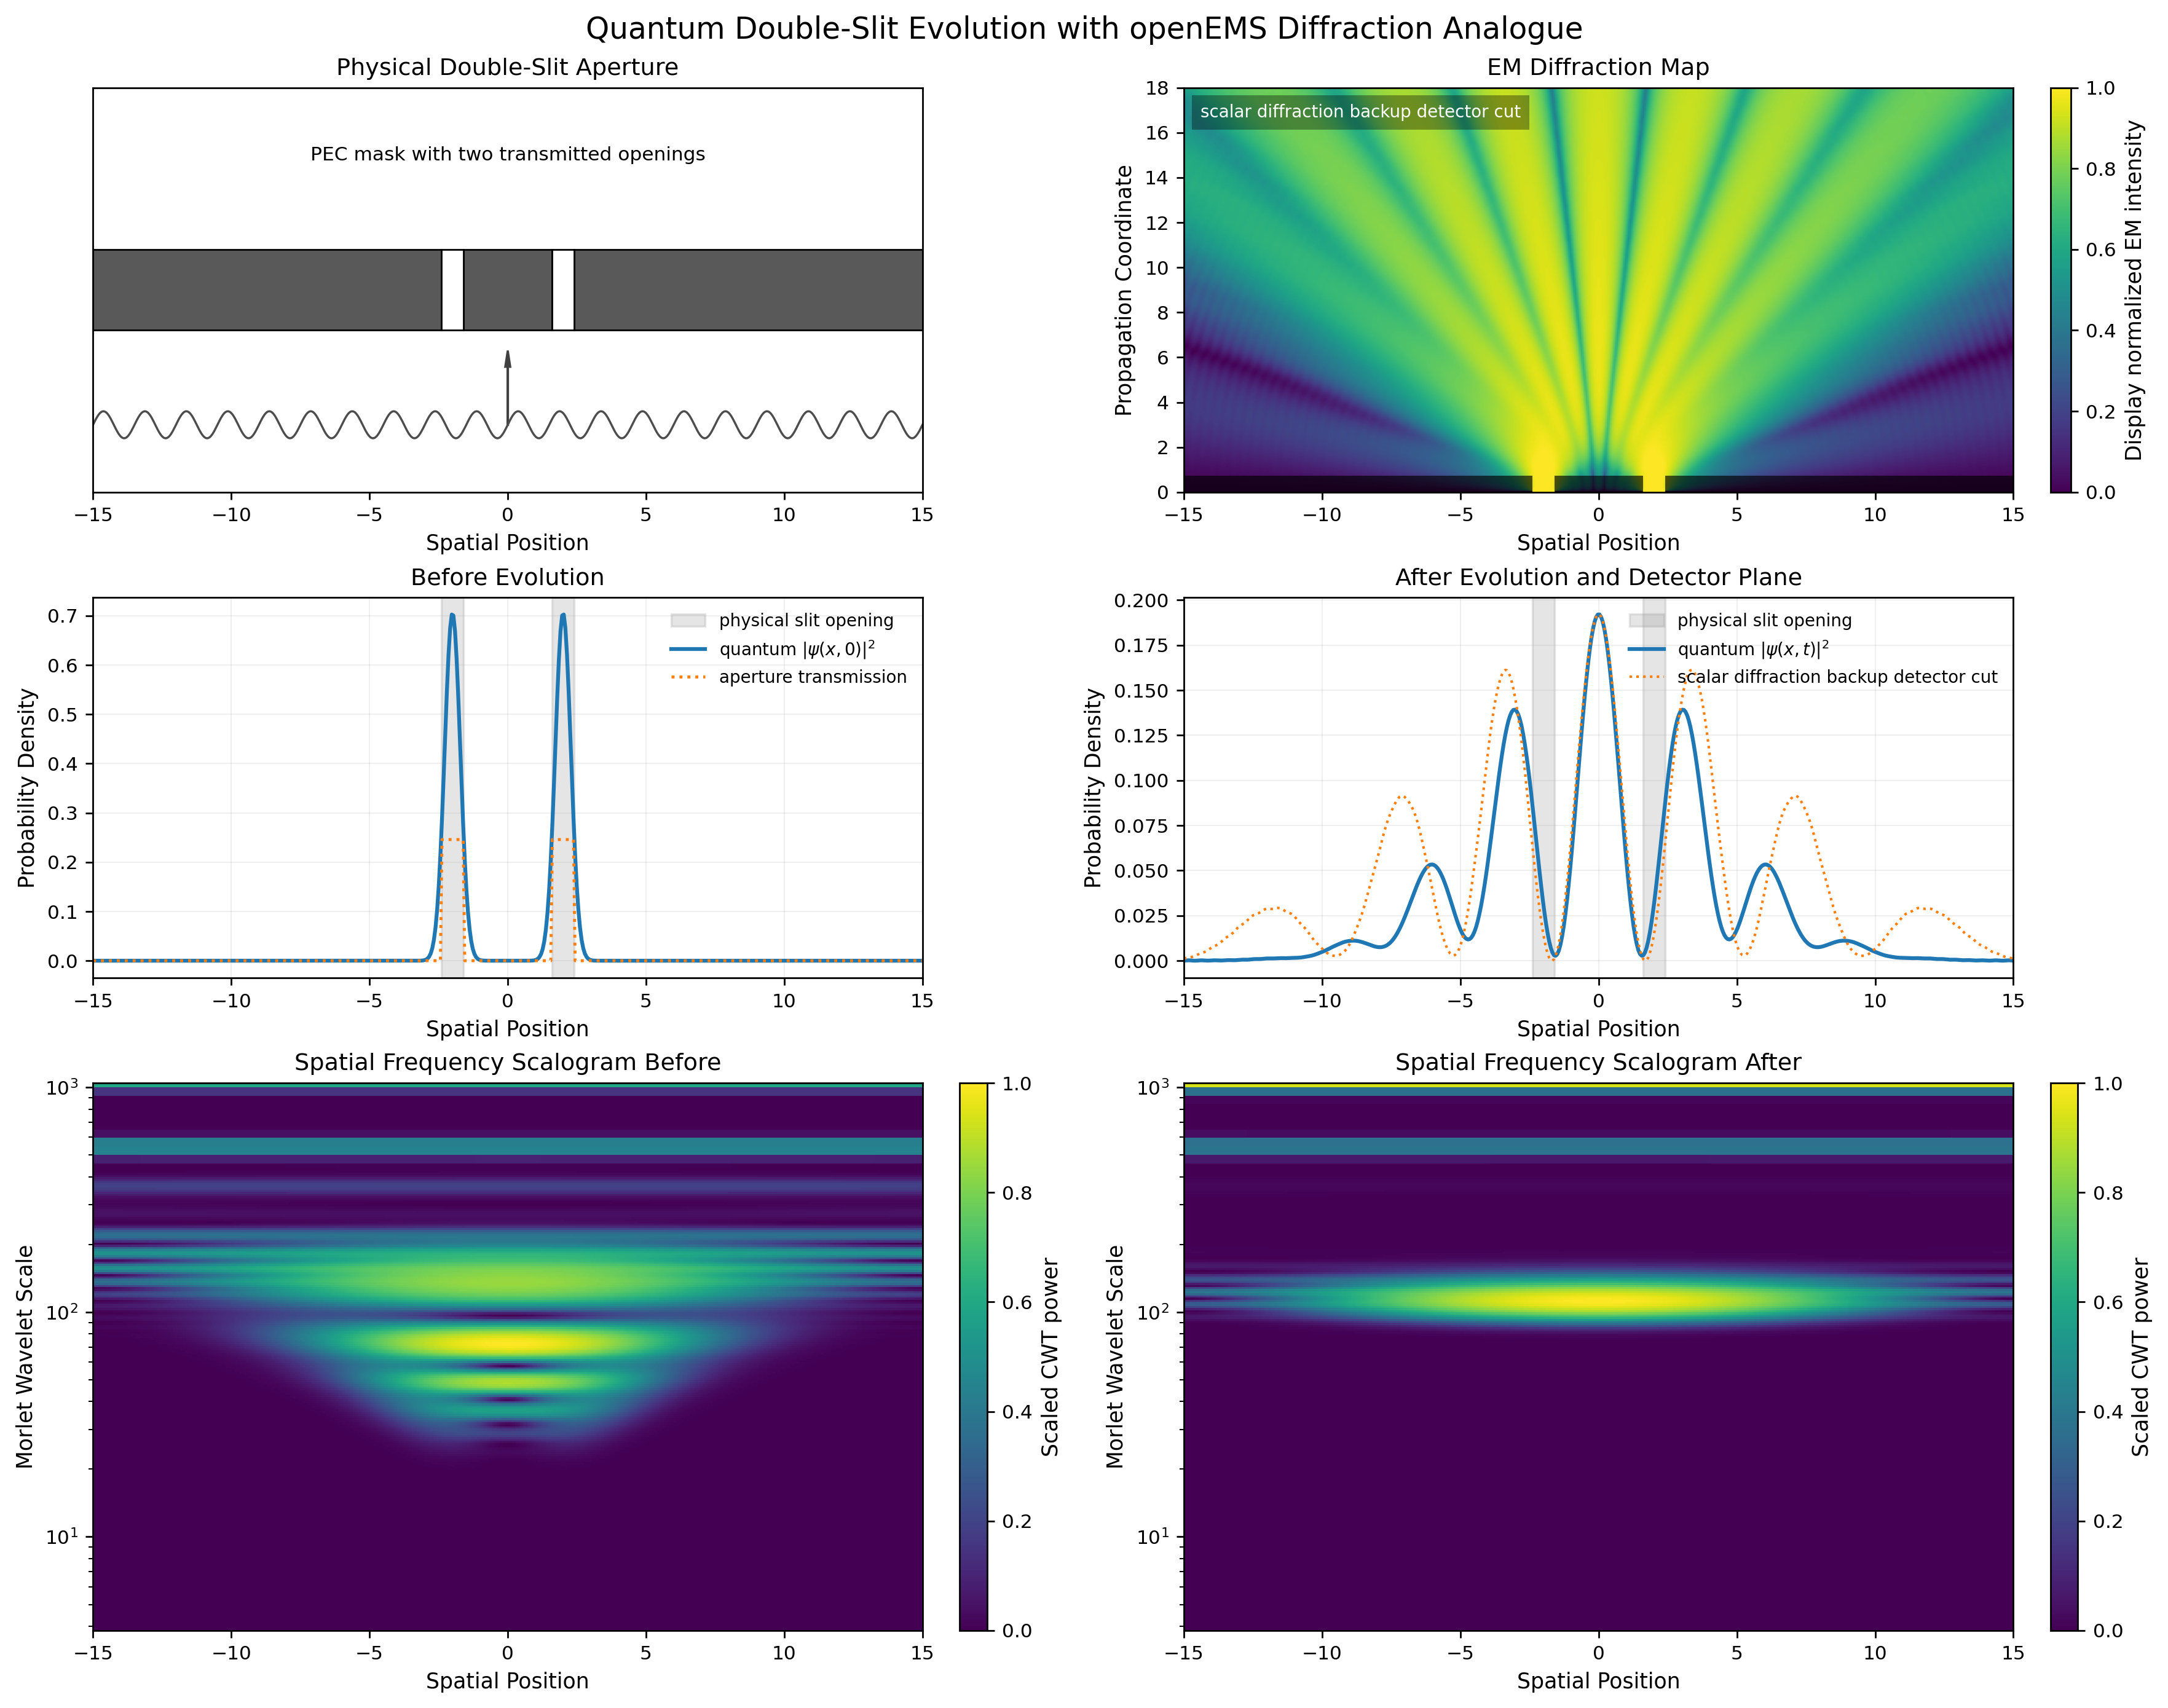

In [3]:
"""Quantum double-slit model with robust openEMS diffraction integration.

The QuTiP section evolves a one-dimensional quantum wavefunction after a
double slit. The openEMS section builds a two-slit PEC aperture using the same
geometry, runs a classical FDTD diffraction analogue, and overlays the detector
line cut on the final quantum probability density. A scalar diffraction backup
renders when the openEMS bridge is unavailable or the FDTD detector plane has
zero energy.
"""

from dataclasses import dataclass, field
from pathlib import Path
import sys
import textwrap

import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
import scipy.ndimage as ndi
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.interpolate import RegularGridInterpolator
from ssqueezepy import cwt


# =============================================================================
# CONTROL KNOBS
# =============================================================================

@dataclass(frozen=True)
class DoubleSlitConfig:
    """User-adjustable settings for the quantum and EM diffraction models."""

    grid_points: int = 512
    x_max: float = 15.0

    slit_separation: float = 4.0
    slit_width: float = 0.4
    physical_slit_width: float = 0.8

    evolution_time: float = 2.0
    particle_mass: float = 1.0
    hbar: float = 1.0

    wavelet_type: str = "morlet"
    cwt_log_gain: float = 35.0
    use_log_wavelet_axis: bool = True

    figure_dpi: int = 250
    figure_size: tuple[float, float] = (14.0, 11.0)

    run_openems: bool = True
    openems_setup_xml: bool = False
    use_scalar_backup: bool = True

    openems_work_dir: str = "/content/openems_double_slit"
    openems_unit_m: float = 1e-6
    openems_wavelength: float = 0.75
    openems_points_per_wavelength: int = 8
    openems_source_y: float = -4.0
    openems_mask_y: float = 0.0
    openems_detector_y: float = 18.0
    openems_y_margin: float = 3.0
    openems_mask_thickness: float = 0.50
    openems_z_half_span: float = 0.20
    openems_end_criteria: float = 0.0
    openems_nr_ts: int = 5500
    openems_fc_fraction: float = 0.12

    em_plot_y_points: int = 260
    detector_average_rows: int = 7
    em_zero_tolerance: float = 1e-18

    em_display_percentile: float = 99.6
    em_display_dynamic_range_db: float = 42.0
    em_display_gamma: float = 0.72
    em_blur_sigma: float = 0.35

    scalar_padding_factor: int = 4

    print_openems_diagnostics: bool = True


@dataclass(frozen=True)
class QuantumResult:
    """Container for the quantum double-slit calculation."""

    x_grid: np.ndarray
    dx: float
    psi_initial: qt.Qobj
    psi_final: qt.Qobj
    prob_initial: np.ndarray
    prob_final: np.ndarray
    cwt_initial: np.ndarray
    cwt_final: np.ndarray
    scales_initial: np.ndarray
    scales_final: np.ndarray


@dataclass(frozen=True)
class EMResult:
    """Container for the EM diffraction analogue."""

    x_grid: np.ndarray
    y_grid: np.ndarray
    intensity_map: np.ndarray
    detector_intensity: np.ndarray
    source_label: str
    used_openems: bool
    metadata: dict[str, str] = field(default_factory=dict)


# =============================================================================
# OPTIONAL OPENEMS BRIDGE IMPORT
# =============================================================================

try:
    sys.path.insert(0, "/content")
    from openems_colab_bridge import run_openems_python_code
    OPENEMS_BRIDGE_AVAILABLE = True
    OPENEMS_BRIDGE_ERROR = ""
except Exception as bridge_error:
    run_openems_python_code = None
    OPENEMS_BRIDGE_AVAILABLE = False
    OPENEMS_BRIDGE_ERROR = str(bridge_error)


# =============================================================================
# GENERAL NUMERICAL HELPERS
# =============================================================================

def configure_matplotlib(config: DoubleSlitConfig) -> None:
    """Apply plotting defaults."""

    mpl.rcParams.update(
        {
            "figure.dpi": config.figure_dpi,
            "font.family": "sans-serif",
            "font.sans-serif": ["Tahoma", "DejaVu Sans", "Arial"],
            "font.weight": "normal",
            "axes.titlesize": 11,
            "axes.labelsize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 8,
        }
    )


def validate_config(config: DoubleSlitConfig) -> None:
    """Validate the core geometry and discretization settings."""

    if config.grid_points < 128:
        raise ValueError("grid_points must be at least 128.")

    if config.x_max <= 0.0:
        raise ValueError("x_max must be positive.")

    if config.slit_width <= 0.0:
        raise ValueError("slit_width must be positive.")

    if config.physical_slit_width <= 0.0:
        raise ValueError("physical_slit_width must be positive.")

    if config.slit_separation <= config.physical_slit_width:
        raise ValueError(
            "slit_separation must exceed physical_slit_width."
        )

    if config.openems_wavelength <= 0.0:
        raise ValueError("openems_wavelength must be positive.")

    if config.openems_points_per_wavelength < 4:
        raise ValueError("openems_points_per_wavelength must be at least 4.")

    if config.openems_detector_y <= config.openems_mask_y:
        raise ValueError("openems_detector_y must exceed openems_mask_y.")

    if config.scalar_padding_factor < 1:
        raise ValueError("scalar_padding_factor must be at least 1.")


def normalize_density(density: np.ndarray, dx: float) -> np.ndarray:
    """Normalize a one-dimensional probability density."""

    density_array = np.real(np.asarray(density, dtype=np.float64))
    density_array = np.maximum(density_array, 0.0)
    area = float(np.sum(density_array) * dx)

    if area <= 0.0:
        raise ValueError("Density integral must be positive.")

    return density_array / area


def normalize_to_unit(values: np.ndarray) -> np.ndarray:
    """Shift and scale an array to the unit interval."""

    value_array = np.asarray(values, dtype=np.float64)
    value_array = np.nan_to_num(
        value_array,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )
    value_array = value_array - np.min(value_array)
    peak = float(np.max(value_array))

    if peak <= 0.0:
        return np.zeros_like(value_array)

    return value_array / peak


def normalize_em_display(
    values: np.ndarray,
    config: DoubleSlitConfig,
) -> np.ndarray:
    """Scale a field map for visible diffraction contrast."""

    value_array = np.asarray(values, dtype=np.float64)
    value_array = np.nan_to_num(
        value_array,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )
    value_array = np.maximum(value_array, 0.0)
    positive = value_array[value_array > config.em_zero_tolerance]

    if positive.size == 0:
        return np.zeros_like(value_array)

    ceiling = float(np.percentile(positive, config.em_display_percentile))
    peak = float(np.max(positive))

    if ceiling <= config.em_zero_tolerance:
        ceiling = peak

    scaled = np.clip(value_array / ceiling, 0.0, 1.0)
    dynamic_gain = 10.0 ** (config.em_display_dynamic_range_db / 10.0)
    scaled = np.log1p((dynamic_gain - 1.0) * scaled)
    scaled = scaled / np.log(dynamic_gain)

    gamma = max(float(config.em_display_gamma), 1e-6)
    scaled = scaled ** gamma

    if config.em_blur_sigma > 0.0:
        scaled = ndi.gaussian_filter(scaled, sigma=config.em_blur_sigma)

    return normalize_to_unit(scaled)


def slit_edges(
    config: DoubleSlitConfig,
) -> tuple[tuple[float, float], tuple[float, float]]:
    """Return physical slit edge coordinates."""

    half_width = 0.5 * config.physical_slit_width
    left_center = -0.5 * config.slit_separation
    right_center = 0.5 * config.slit_separation

    left_edges = (left_center - half_width, left_center + half_width)
    right_edges = (right_center - half_width, right_center + half_width)

    return left_edges, right_edges


def aperture_transmission(
    x_grid: np.ndarray,
    config: DoubleSlitConfig,
) -> np.ndarray:
    """Return a binary aperture transmission function."""

    left_edges, right_edges = slit_edges(config)

    left_open = (x_grid >= left_edges[0]) & (x_grid <= left_edges[1])
    right_open = (x_grid >= right_edges[0]) & (x_grid <= right_edges[1])

    return (left_open | right_open).astype(np.float64)


# =============================================================================
# QUANTUM DOUBLE-SLIT MODEL
# =============================================================================

def generate_double_slit_state(
    x_grid: np.ndarray,
    dx: float,
    config: DoubleSlitConfig,
) -> qt.Qobj:
    """Generate a continuum-normalized post-slit quantum state."""

    left_center = -0.5 * config.slit_separation
    right_center = 0.5 * config.slit_separation

    psi_left = np.exp(
        -0.5 * ((x_grid - left_center) / config.slit_width) ** 2
    )
    psi_right = np.exp(
        -0.5 * ((x_grid - right_center) / config.slit_width) ** 2
    )

    continuum_psi = psi_left + psi_right
    continuum_norm = np.sqrt(np.sum(np.abs(continuum_psi) ** 2) * dx)

    if continuum_norm <= 0.0:
        raise ValueError("Initial wavefunction norm must be positive.")

    continuum_psi = continuum_psi / continuum_norm
    lattice_state = continuum_psi * np.sqrt(dx)

    return qt.Qobj(lattice_state.astype(np.complex128))


def construct_free_hamiltonian(
    n_points: int,
    dx: float,
    config: DoubleSlitConfig,
) -> sp.csr_matrix:
    """Construct a one-dimensional finite-difference kinetic Hamiltonian."""

    kinetic_coefficient = (
        config.hbar**2 / (2.0 * config.particle_mass * dx**2)
    )

    main_diagonal = 2.0 * np.ones(n_points)
    off_diagonal = -1.0 * np.ones(n_points - 1)

    laplacian_matrix = sp.diags(
        diagonals=[off_diagonal, main_diagonal, off_diagonal],
        offsets=[-1, 0, 1],
        format="csr",
        dtype=np.complex128,
    )

    return kinetic_coefficient * laplacian_matrix


def evolve_quantum_state(
    psi_initial: qt.Qobj,
    hamiltonian: sp.csr_matrix,
    config: DoubleSlitConfig,
) -> qt.Qobj:
    """Evolve the state with a sparse exponential action."""

    initial_vector = np.asarray(psi_initial.full()).reshape(-1)
    generator = -1j * hamiltonian * (config.evolution_time / config.hbar)
    final_vector = spla.expm_multiply(generator, initial_vector)
    final_vector = final_vector / np.linalg.norm(final_vector)

    return qt.Qobj(final_vector)


def probability_density_from_state(state: qt.Qobj, dx: float) -> np.ndarray:
    """Convert a lattice-normalized state into a spatial density."""

    state_vector = np.asarray(state.full()).reshape(-1)
    density = np.abs(state_vector) ** 2 / dx
    return normalize_density(density, dx)


def compute_cwt_power(
    signal: np.ndarray,
    config: DoubleSlitConfig,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute a normalized logarithmic continuous wavelet power map."""

    prepared_signal = np.asarray(signal, dtype=np.float64)
    prepared_signal = prepared_signal - np.mean(prepared_signal)
    peak = float(np.max(np.abs(prepared_signal)))

    if peak <= 0.0:
        raise ValueError("CWT input signal peak must be positive.")

    prepared_signal = prepared_signal / peak
    coefficients, scales = cwt(prepared_signal, wavelet=config.wavelet_type)

    power = normalize_to_unit(np.abs(coefficients) ** 2)
    log_power = np.log1p(config.cwt_log_gain * power)
    log_power = normalize_to_unit(log_power)

    return log_power, np.asarray(scales, dtype=np.float64)


def compute_quantum_result(config: DoubleSlitConfig) -> QuantumResult:
    """Compute the quantum propagation and wavelet diagnostics."""

    x_grid = np.linspace(-config.x_max, config.x_max, config.grid_points)
    dx = float(x_grid[1] - x_grid[0])

    psi_initial = generate_double_slit_state(x_grid, dx, config)
    hamiltonian = construct_free_hamiltonian(config.grid_points, dx, config)
    psi_final = evolve_quantum_state(psi_initial, hamiltonian, config)

    prob_initial = probability_density_from_state(psi_initial, dx)
    prob_final = probability_density_from_state(psi_final, dx)

    cwt_initial, scales_initial = compute_cwt_power(prob_initial, config)
    cwt_final, scales_final = compute_cwt_power(prob_final, config)

    return QuantumResult(
        x_grid=x_grid,
        dx=dx,
        psi_initial=psi_initial,
        psi_final=psi_final,
        prob_initial=prob_initial,
        prob_final=prob_final,
        cwt_initial=cwt_initial,
        cwt_final=cwt_final,
        scales_initial=scales_initial,
        scales_final=scales_final,
    )


# =============================================================================
# OPENEMS INTEGRATION
# =============================================================================

def build_openems_script(config: DoubleSlitConfig) -> str:
    """Create a standalone openEMS runner executed by the Colab bridge."""

    work_dir = Path(config.openems_work_dir)
    sim_dir = work_dir / "fdtd_run"
    output_path = work_dir / "openems_raw_result.npz"

    params = {
        "x_max": config.x_max,
        "slit_separation": config.slit_separation,
        "physical_slit_width": config.physical_slit_width,
        "unit_m": config.openems_unit_m,
        "wavelength": config.openems_wavelength,
        "points_per_wavelength": config.openems_points_per_wavelength,
        "source_y": config.openems_source_y,
        "mask_y": config.openems_mask_y,
        "detector_y": config.openems_detector_y,
        "y_margin": config.openems_y_margin,
        "mask_thickness": config.openems_mask_thickness,
        "z_half_span": config.openems_z_half_span,
        "end_criteria": config.openems_end_criteria,
        "nr_ts": config.openems_nr_ts,
        "fc_fraction": config.openems_fc_fraction,
        "setup_xml": config.openems_setup_xml,
        "sim_dir": str(sim_dir),
        "output_path": str(output_path),
    }

    script_template = r"""
from pathlib import Path
import shutil

import h5py
import numpy as np

from CSXCAD import ContinuousStructure
from openEMS import openEMS
from openEMS.physical_constants import C0


PARAMS = __PARAMS__


def normalize_to_unit(values):
    value_array = np.asarray(values, dtype=np.float64)
    value_array = np.nan_to_num(
        value_array,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )
    value_array = value_array - np.min(value_array)
    peak = float(np.max(value_array))

    if peak <= 0.0:
        return np.zeros_like(value_array)

    return value_array / peak


def slit_edges():
    half_width = 0.5 * PARAMS["physical_slit_width"]
    left_center = -0.5 * PARAMS["slit_separation"]
    right_center = 0.5 * PARAMS["slit_separation"]

    return (
        (left_center - half_width, left_center + half_width),
        (right_center - half_width, right_center + half_width),
    )


def unique_lines(values):
    return np.unique(np.round(np.asarray(values, dtype=np.float64), 9))


def add_box_if_valid(property_object, start, stop):
    start_array = np.asarray(start, dtype=np.float64)
    stop_array = np.asarray(stop, dtype=np.float64)

    if np.all(stop_array > start_array):
        property_object.AddBox(start_array.tolist(), stop_array.tolist())


def complex_from_compound(array):
    fields = array.dtype.fields

    if fields is None:
        return array

    names = list(fields.keys())
    lower_names = [name.lower() for name in names]

    real_name = None
    imag_name = None

    for candidate in ("r", "re", "real"):
        if candidate in lower_names:
            real_name = names[lower_names.index(candidate)]

    for candidate in ("i", "im", "imag", "imaginary"):
        if candidate in lower_names:
            imag_name = names[lower_names.index(candidate)]

    if real_name is None and len(names) >= 2:
        real_name = names[0]

    if imag_name is None and len(names) >= 2:
        imag_name = names[1]

    if real_name is None or imag_name is None:
        return None

    return (
        np.asarray(array[real_name], dtype=np.float64)
        + 1j * np.asarray(array[imag_name], dtype=np.float64)
    )


def numeric_array_from_dataset(dataset):
    try:
        raw_array = np.asarray(dataset[()])
    except Exception:
        return None

    if raw_array.dtype.fields is None:
        if np.issubdtype(raw_array.dtype, np.number):
            return raw_array
        return None

    return complex_from_compound(raw_array)


def reduce_field_dataset_to_power(dataset):
    array = numeric_array_from_dataset(dataset)

    if array is None:
        return None

    if array.size < 128:
        return None

    array = np.squeeze(array)

    if array.ndim < 2:
        return None

    array = np.nan_to_num(
        array,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    magnitude = np.abs(array)

    thin_axes = [
        axis
        for axis, size in enumerate(magnitude.shape)
        if size <= 3 and magnitude.ndim > 2
    ]

    for axis in reversed(thin_axes):
        magnitude = np.sqrt(np.mean(magnitude**2, axis=axis))

    magnitude = np.squeeze(magnitude)

    while magnitude.ndim > 2:
        reduction_axis = int(np.argmin(magnitude.shape))
        magnitude = np.max(magnitude, axis=reduction_axis)

    if magnitude.ndim != 2:
        return None

    power = np.asarray(magnitude**2, dtype=np.float64)
    peak = float(np.max(power))

    if peak <= 0.0:
        return None

    return power


def extract_best_hdf5_map(sim_dir):
    hdf5_files = sorted(Path(sim_dir).rglob("*.h5"))

    if len(hdf5_files) == 0:
        raise RuntimeError("Zero HDF5 field dump files were found.")

    best_map = None
    best_score = -1
    best_h5 = ""
    best_dataset = ""

    for hdf5_file in hdf5_files:
        with h5py.File(hdf5_file, "r") as handle:
            dataset_paths = []

            def visitor(path, obj):
                if isinstance(obj, h5py.Dataset):
                    dataset_paths.append(path)

            handle.visititems(visitor)

            for dataset_path in dataset_paths:
                dataset = handle[dataset_path]
                candidate = reduce_field_dataset_to_power(dataset)

                if candidate is None:
                    continue

                text_path = (str(hdf5_file.name) + "/" + dataset_path).lower()
                score = int(candidate.size)

                if "fielddata" in text_path:
                    score += 1_000_000_000

                if "ez" in text_path:
                    score += 100_000_000

                if "fd" in text_path:
                    score += 10_000_000

                if score > best_score:
                    best_score = score
                    best_map = candidate
                    best_h5 = str(hdf5_file)
                    best_dataset = dataset_path

    if best_map is None:
        raise RuntimeError("Zero usable 2D numeric field maps were found.")

    return best_map, best_h5, best_dataset


def setup_and_run_openems():
    sim_dir = Path(PARAMS["sim_dir"])
    output_path = Path(PARAMS["output_path"])

    if sim_dir.exists():
        shutil.rmtree(sim_dir)

    sim_dir.mkdir(parents=True, exist_ok=True)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    f0 = C0 / (PARAMS["wavelength"] * PARAMS["unit_m"])
    fc = PARAMS["fc_fraction"] * f0

    fdtd = openEMS(
        NrTS=PARAMS["nr_ts"],
        EndCriteria=PARAMS["end_criteria"],
    )
    fdtd.SetGaussExcite(f0, fc)
    fdtd.SetBoundaryCond(
        ["PML_8", "PML_8", "PML_8", "PML_8", "PMC", "PMC"]
    )

    csx = ContinuousStructure()
    fdtd.SetCSX(csx)

    mesh = csx.GetGrid()
    mesh.SetDeltaUnit(PARAMS["unit_m"])

    max_cell = PARAMS["wavelength"] / PARAMS["points_per_wavelength"]

    x_min = -PARAMS["x_max"]
    x_max = PARAMS["x_max"]
    y_min = PARAMS["source_y"] - PARAMS["y_margin"]
    y_max = PARAMS["detector_y"] + PARAMS["y_margin"]

    left_edges, right_edges = slit_edges()

    x_base = np.arange(x_min, x_max + max_cell, max_cell)
    x_features = np.array(
        [
            x_min,
            x_max,
            0.0,
            left_edges[0],
            left_edges[1],
            right_edges[0],
            right_edges[1],
        ]
    )
    x_lines = unique_lines(np.concatenate([x_base, x_features]))

    y_base = np.arange(y_min, y_max + max_cell, max_cell)
    y_features = np.array(
        [
            y_min,
            y_max,
            PARAMS["source_y"],
            PARAMS["mask_y"],
            PARAMS["mask_y"] - 0.5 * PARAMS["mask_thickness"],
            PARAMS["mask_y"] + 0.5 * PARAMS["mask_thickness"],
            PARAMS["detector_y"],
        ]
    )
    y_lines = unique_lines(np.concatenate([y_base, y_features]))

    dump_y_min = PARAMS["mask_y"] + 0.5 * PARAMS["mask_thickness"]
    dump_y_max = PARAMS["detector_y"]
    dump_y_lines = y_lines[
        (y_lines >= dump_y_min - 1e-9) & (y_lines <= dump_y_max + 1e-9)
    ]

    z_lines = np.array(
        [
            -PARAMS["z_half_span"],
            0.0,
            PARAMS["z_half_span"],
        ]
    )

    mesh.SetLines("x", x_lines)
    mesh.SetLines("y", y_lines)
    mesh.SetLines("z", z_lines)
    mesh.SmoothMeshLines("x", max_cell)
    mesh.SmoothMeshLines("y", max_cell)

    mask = csx.AddMetal("pec_double_slit_mask")

    y0 = PARAMS["mask_y"] - 0.5 * PARAMS["mask_thickness"]
    y1 = PARAMS["mask_y"] + 0.5 * PARAMS["mask_thickness"]
    z0 = -PARAMS["z_half_span"]
    z1 = PARAMS["z_half_span"]

    opaque_regions = [
        (x_min, left_edges[0]),
        (left_edges[1], right_edges[0]),
        (right_edges[1], x_max),
    ]

    for region_start, region_stop in opaque_regions:
        add_box_if_valid(
            mask,
            [region_start, y0, z0],
            [region_stop, y1, z1],
        )

    source = csx.AddExcitation(
        "ez_soft_source",
        exc_type=0,
        exc_val=[0.0, 0.0, 1.0],
    )
    source.AddBox(
        [x_min, PARAMS["source_y"] - 0.5 * max_cell, z0],
        [x_max, PARAMS["source_y"] + 0.5 * max_cell, z1],
    )

    field_dump = csx.AddDump(
        "Ez_fd",
        dump_type=10,
        dump_mode=1,
        file_type=1,
        frequency=[f0],
    )
    field_dump.AddBox(
        [x_min, dump_y_min, z0],
        [x_max, dump_y_max, z1],
    )

    if PARAMS["setup_xml"]:
        xml_path = sim_dir / "double_slit.xml"
        csx.Write2XML(str(xml_path))
        np.savez_compressed(
            output_path,
            raw_map=np.zeros((2, 2), dtype=np.float64),
            x_lines=x_lines,
            y_lines=y_lines,
            dump_y_lines=dump_y_lines,
            used_openems=np.array([0], dtype=np.int32),
            setup_xml=np.array([1], dtype=np.int32),
            selected_h5=np.array([""], dtype="U512"),
            selected_dataset=np.array([""], dtype="U512"),
        )
        print("openEMS XML written:", xml_path)
        return

    fdtd.Run(str(sim_dir), cleanup=False)

    raw_map, selected_h5, selected_dataset = extract_best_hdf5_map(sim_dir)
    np.savez_compressed(
        output_path,
        raw_map=raw_map,
        x_lines=x_lines,
        y_lines=y_lines,
        dump_y_lines=dump_y_lines,
        used_openems=np.array([1], dtype=np.int32),
        setup_xml=np.array([0], dtype=np.int32),
        selected_h5=np.array([selected_h5], dtype="U512"),
        selected_dataset=np.array([selected_dataset], dtype="U512"),
        raw_shape=np.asarray(raw_map.shape, dtype=np.int32),
    )
    print("openEMS raw field map saved:", output_path)
    print("selected HDF5 file:", selected_h5)
    print("selected HDF5 dataset:", selected_dataset)
    print("raw map shape:", raw_map.shape)


setup_and_run_openems()
"""

    return (
        textwrap.dedent(script_template)
        .replace("__PARAMS__", repr(params))
        .strip()
    )


def axis_for_length(axis_lines: np.ndarray, target_length: int) -> np.ndarray:
    """Create an interpolation axis with the requested length."""

    axis = np.asarray(axis_lines, dtype=np.float64).reshape(-1)

    if axis.size == target_length:
        return axis

    if axis.size == target_length + 1:
        return 0.5 * (axis[:-1] + axis[1:])

    if axis.size < 2:
        return np.linspace(0.0, float(target_length - 1), target_length)

    return np.linspace(float(axis[0]), float(axis[-1]), target_length)


def sort_axis_and_values(
    axis: np.ndarray,
    values: np.ndarray,
    axis_index: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Sort an axis and the matching data dimension."""

    axis_array = np.asarray(axis, dtype=np.float64).reshape(-1)
    order = np.argsort(axis_array)
    sorted_axis = axis_array[order]
    sorted_values = np.take(values, order, axis=axis_index)

    unique_axis, unique_indices = np.unique(sorted_axis, return_index=True)
    unique_values = np.take(sorted_values, unique_indices, axis=axis_index)

    return unique_axis, unique_values


def choose_openems_orientation(
    raw_map: np.ndarray,
    x_lines: np.ndarray,
    y_lines: np.ndarray,
    dump_y_lines: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Orient a raw openEMS map into rows as y and columns as x."""

    raw = np.asarray(raw_map, dtype=np.float64)
    raw = np.squeeze(raw)

    if raw.ndim != 2:
        raise ValueError("openEMS field map must reduce to a 2D array.")

    y_choices = [np.asarray(y_lines, dtype=np.float64)]

    if np.asarray(dump_y_lines).size >= 2:
        y_choices.insert(0, np.asarray(dump_y_lines, dtype=np.float64))

    options = []

    for y_axis_source in y_choices:
        score_xy = (
            abs(raw.shape[0] - np.asarray(x_lines).size)
            + abs(raw.shape[1] - np.asarray(y_axis_source).size)
        )
        options.append((score_xy, "xy", y_axis_source))

        score_yx = (
            abs(raw.shape[0] - np.asarray(y_axis_source).size)
            + abs(raw.shape[1] - np.asarray(x_lines).size)
        )
        options.append((score_yx, "yx", y_axis_source))

    _, orientation, y_axis_source = min(options, key=lambda item: item[0])

    if orientation == "xy":
        oriented = raw.T
        x_axis = axis_for_length(x_lines, oriented.shape[1])
        y_axis = axis_for_length(y_axis_source, oriented.shape[0])
    else:
        oriented = raw
        x_axis = axis_for_length(x_lines, oriented.shape[1])
        y_axis = axis_for_length(y_axis_source, oriented.shape[0])

    x_axis, oriented = sort_axis_and_values(x_axis, oriented, axis_index=1)
    y_axis, oriented = sort_axis_and_values(y_axis, oriented, axis_index=0)

    return oriented, x_axis, y_axis


def crop_resample_openems_map(
    raw_map: np.ndarray,
    x_grid: np.ndarray,
    x_lines: np.ndarray,
    y_lines: np.ndarray,
    dump_y_lines: np.ndarray,
    config: DoubleSlitConfig,
) -> tuple[np.ndarray, np.ndarray]:
    """Crop and resample the raw openEMS field map."""

    oriented, x_axis, y_axis = choose_openems_orientation(
        raw_map=raw_map,
        x_lines=x_lines,
        y_lines=y_lines,
        dump_y_lines=dump_y_lines,
    )

    y_min = config.openems_mask_y
    y_max = config.openems_detector_y
    crop_mask = (y_axis >= y_min) & (y_axis <= y_max)

    if int(np.count_nonzero(crop_mask)) >= 2:
        oriented = oriented[crop_mask, :]
        y_axis = y_axis[crop_mask]

    y_target = np.linspace(y_min, y_max, config.em_plot_y_points)
    interpolator = RegularGridInterpolator(
        (y_axis, x_axis),
        oriented,
        bounds_error=False,
        fill_value=0.0,
    )

    y_mesh, x_mesh = np.meshgrid(y_target, x_grid, indexing="ij")
    points = np.column_stack((y_mesh.ravel(), x_mesh.ravel()))
    resampled = interpolator(points).reshape(y_target.size, x_grid.size)
    resampled = np.nan_to_num(
        resampled,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )
    resampled = np.maximum(resampled, 0.0)

    return resampled, y_target


def run_openems_result(
    x_grid: np.ndarray,
    config: DoubleSlitConfig,
) -> EMResult:
    """Run openEMS and return a processed EM result."""

    output_path = Path(config.openems_work_dir) / "openems_raw_result.npz"
    script = build_openems_script(config)

    if run_openems_python_code is None:
        raise RuntimeError("openEMS Python bridge function is unavailable.")

    run_openems_python_code(
        script,
        work_dir=config.openems_work_dir,
        filename="openems_double_slit_case.py",
        check=True,
    )

    if output_path.exists():
        data = np.load(output_path, allow_pickle=False)
    else:
        raise RuntimeError("openEMS NPZ output file is absent.")

    used_openems = bool(int(data["used_openems"][0]))

    if used_openems is False:
        raise RuntimeError("openEMS XML setup completed with zero field output.")

    x_lines = data["x_lines"]
    y_lines = data["y_lines"]
    dump_y_lines = data["dump_y_lines"]

    raw_intensity_map, y_grid = crop_resample_openems_map(
        raw_map=data["raw_map"],
        x_grid=x_grid,
        x_lines=x_lines,
        y_lines=y_lines,
        dump_y_lines=dump_y_lines,
        config=config,
    )

    row_count = max(1, int(config.detector_average_rows))
    detector_intensity = np.mean(raw_intensity_map[-row_count:, :], axis=0)
    detector_peak = float(np.max(detector_intensity))

    if detector_peak <= config.em_zero_tolerance:
        raise RuntimeError(
            "openEMS detector plane energy is zero. Increase openems_nr_ts "
            "or reduce openems_detector_y."
        )

    detector_intensity = normalize_to_unit(detector_intensity)
    display_map = normalize_em_display(raw_intensity_map, config)

    metadata = {
        "selected_h5": "",
        "selected_dataset": "",
        "raw_shape": str(tuple(np.asarray(data["raw_map"]).shape)),
        "detector_peak": f"{detector_peak:.6e}",
    }

    if "selected_h5" in data.files:
        metadata["selected_h5"] = str(data["selected_h5"][0])

    if "selected_dataset" in data.files:
        metadata["selected_dataset"] = str(data["selected_dataset"][0])

    if config.print_openems_diagnostics:
        print("openEMS processed raw shape:", metadata["raw_shape"])
        print("openEMS selected HDF5:", metadata["selected_h5"])
        print("openEMS selected dataset:", metadata["selected_dataset"])
        print("openEMS detector peak:", metadata["detector_peak"])

    return EMResult(
        x_grid=x_grid,
        y_grid=y_grid,
        intensity_map=display_map,
        detector_intensity=detector_intensity,
        source_label="openEMS FDTD detector cut",
        used_openems=True,
        metadata=metadata,
    )


# =============================================================================
# SCALAR DIFFRACTION BACKUP
# =============================================================================

def angular_spectrum_propagate(
    field: np.ndarray,
    dx: float,
    propagation_distance: float,
    wavelength: float,
    padding_factor: int,
) -> np.ndarray:
    """Propagate a scalar field using the angular spectrum method."""

    n_points = int(field.size)
    padded_points = int(max(padding_factor, 1) * n_points)
    start = (padded_points - n_points) // 2
    stop = start + n_points

    padded_field = np.zeros(padded_points, dtype=np.complex128)
    padded_field[start:stop] = field

    k0 = 2.0 * np.pi / wavelength
    kx = 2.0 * np.pi * np.fft.fftfreq(padded_points, d=dx)
    kz = np.sqrt((k0**2 - kx**2).astype(np.complex128))

    spectrum = np.fft.fft(padded_field)
    propagated = np.fft.ifft(spectrum * np.exp(1j * kz * propagation_distance))

    return propagated[start:stop]


def compute_scalar_em_result(
    x_grid: np.ndarray,
    config: DoubleSlitConfig,
) -> EMResult:
    """Compute a scalar diffraction backup using the same aperture geometry."""

    dx = float(x_grid[1] - x_grid[0])
    y_grid = np.linspace(
        config.openems_mask_y,
        config.openems_detector_y,
        config.em_plot_y_points,
    )

    aperture = aperture_transmission(x_grid, config).astype(np.complex128)
    raw_intensity_map = np.zeros((y_grid.size, x_grid.size), dtype=np.float64)

    for index, y_value in enumerate(y_grid):
        distance = y_value - config.openems_mask_y
        propagated = angular_spectrum_propagate(
            aperture,
            dx,
            distance,
            config.openems_wavelength,
            config.scalar_padding_factor,
        )
        raw_intensity_map[index, :] = np.abs(propagated) ** 2

    row_count = max(1, int(config.detector_average_rows))
    detector_intensity = np.mean(raw_intensity_map[-row_count:, :], axis=0)
    detector_intensity = normalize_to_unit(detector_intensity)
    display_map = normalize_em_display(raw_intensity_map, config)

    return EMResult(
        x_grid=x_grid,
        y_grid=y_grid,
        intensity_map=display_map,
        detector_intensity=detector_intensity,
        source_label="scalar diffraction backup detector cut",
        used_openems=False,
        metadata={},
    )


def compute_em_result(
    x_grid: np.ndarray,
    config: DoubleSlitConfig,
) -> EMResult:
    """Compute openEMS diffraction data with scalar backup as needed."""

    if config.run_openems and OPENEMS_BRIDGE_AVAILABLE:
        try:
            return run_openems_result(x_grid, config)
        except Exception as error:
            print("openEMS run failed. Scalar diffraction backup used.")
            print(f"Reason: {error}")

    if config.run_openems and (OPENEMS_BRIDGE_AVAILABLE is False):
        print("openEMS bridge unavailable. Scalar diffraction backup used.")
        print(f"Bridge import detail: {OPENEMS_BRIDGE_ERROR}")

    if config.use_scalar_backup:
        return compute_scalar_em_result(x_grid, config)

    raise RuntimeError("EM diffraction result unavailable.")


# =============================================================================
# PLOTTING
# =============================================================================

def add_slit_spans(ax: plt.Axes, config: DoubleSlitConfig) -> None:
    """Add shaded slit openings to a one-dimensional plot."""

    left_edges, right_edges = slit_edges(config)

    ax.axvspan(
        left_edges[0],
        left_edges[1],
        alpha=0.25,
        color="0.6",
        label="physical slit opening",
    )
    ax.axvspan(
        right_edges[0],
        right_edges[1],
        alpha=0.25,
        color="0.6",
    )


def draw_aperture_schematic(
    ax: plt.Axes,
    config: DoubleSlitConfig,
) -> None:
    """Draw the physical double-slit mask and incoming wavefront."""

    ax.set_xlim(-config.x_max, config.x_max)
    ax.set_ylim(-1.5, 1.5)
    ax.set_title("Physical Double-Slit Aperture")
    ax.set_xlabel("Spatial Position")
    ax.set_yticks([])

    left_edges, right_edges = slit_edges(config)
    x_min = -config.x_max
    x_max = config.x_max

    opaque_regions = [
        (x_min, left_edges[0]),
        (left_edges[1], right_edges[0]),
        (right_edges[1], x_max),
    ]

    for start, stop in opaque_regions:
        width = stop - start
        if width > 0.0:
            ax.add_patch(
                patches.Rectangle(
                    (start, -0.30),
                    width,
                    0.60,
                    facecolor="0.35",
                    edgecolor="black",
                    linewidth=0.8,
                )
            )

    for start, stop in (left_edges, right_edges):
        ax.add_patch(
            patches.Rectangle(
                (start, -0.30),
                stop - start,
                0.60,
                facecolor="white",
                edgecolor="black",
                linewidth=0.8,
            )
        )

    x_wave = np.linspace(-config.x_max, config.x_max, 800)
    y_wave = -1.0 + 0.10 * np.sin(2.0 * np.pi * x_wave / 1.5)
    ax.plot(x_wave, y_wave, linewidth=1.0, color="0.3")
    ax.arrow(
        0.0,
        -1.0,
        0.0,
        0.55,
        width=0.015,
        head_width=0.18,
        head_length=0.12,
        length_includes_head=True,
        color="0.25",
    )
    ax.text(
        0.0,
        1.0,
        "PEC mask with two transmitted openings",
        ha="center",
        va="center",
        fontsize=9,
    )


def plot_em_map(
    fig: plt.Figure,
    ax: plt.Axes,
    em_result: EMResult,
    config: DoubleSlitConfig,
) -> None:
    """Plot the openEMS or scalar diffraction map."""

    extent = [
        em_result.x_grid[0],
        em_result.x_grid[-1],
        em_result.y_grid[0],
        em_result.y_grid[-1],
    ]

    mesh = ax.imshow(
        em_result.intensity_map,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
    )

    ax.set_title("EM Diffraction Map")
    ax.set_xlabel("Spatial Position")
    ax.set_ylabel("Propagation Coordinate")

    left_edges, right_edges = slit_edges(config)
    mask_height = 0.04 * (em_result.y_grid[-1] - em_result.y_grid[0])
    y0 = em_result.y_grid[0]
    opaque_regions = [
        (em_result.x_grid[0], left_edges[0]),
        (left_edges[1], right_edges[0]),
        (right_edges[1], em_result.x_grid[-1]),
    ]

    for start, stop in opaque_regions:
        width = stop - start
        if width > 0.0:
            ax.add_patch(
                patches.Rectangle(
                    (start, y0),
                    width,
                    mask_height,
                    facecolor="black",
                    alpha=0.65,
                    linewidth=0.0,
                )
            )

    ax.axhline(
        config.openems_detector_y,
        color="white",
        linewidth=0.8,
        alpha=0.75,
    )
    ax.text(
        0.02,
        0.96,
        em_result.source_label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8,
        color="white",
        bbox={"facecolor": "black", "alpha": 0.35, "linewidth": 0.0},
    )

    colorbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.03)
    colorbar.set_label("Display normalized EM intensity")


def plot_probability_profiles(
    ax_before: plt.Axes,
    ax_after: plt.Axes,
    quantum: QuantumResult,
    em_result: EMResult,
    config: DoubleSlitConfig,
) -> None:
    """Plot one-dimensional profiles with EM overlays."""

    aperture = aperture_transmission(quantum.x_grid, config)
    initial_peak = float(np.max(quantum.prob_initial))
    final_peak = float(np.max(quantum.prob_final))

    add_slit_spans(ax_before, config)
    ax_before.plot(
        quantum.x_grid,
        quantum.prob_initial,
        linewidth=1.8,
        label=r"quantum $|\psi(x,0)|^2$",
    )
    ax_before.plot(
        quantum.x_grid,
        0.35 * initial_peak * aperture,
        linewidth=1.4,
        linestyle=":",
        label="aperture transmission",
    )
    ax_before.set_title("Before Evolution")
    ax_before.set_xlabel("Spatial Position")
    ax_before.set_ylabel(r"Probability Density")
    ax_before.set_xlim(quantum.x_grid[0], quantum.x_grid[-1])
    ax_before.grid(alpha=0.20, linewidth=0.6)
    ax_before.legend(loc="upper right", frameon=False)

    add_slit_spans(ax_after, config)
    ax_after.plot(
        quantum.x_grid,
        quantum.prob_final,
        linewidth=1.8,
        label=r"quantum $|\psi(x,t)|^2$",
    )
    ax_after.plot(
        em_result.x_grid,
        final_peak * em_result.detector_intensity,
        linewidth=1.2,
        linestyle=":",
        label=em_result.source_label,
    )
    ax_after.set_title("After Evolution and Detector Plane")
    ax_after.set_xlabel("Spatial Position")
    ax_after.set_ylabel(r"Probability Density")
    ax_after.set_xlim(quantum.x_grid[0], quantum.x_grid[-1])
    ax_after.grid(alpha=0.20, linewidth=0.6)
    ax_after.legend(loc="upper right", frameon=False)


def plot_cwt_map(
    fig: plt.Figure,
    ax: plt.Axes,
    x_grid: np.ndarray,
    scales: np.ndarray,
    cwt_power: np.ndarray,
    title: str,
    config: DoubleSlitConfig,
) -> None:
    """Render a CWT power map."""

    mesh = ax.pcolormesh(
        x_grid,
        scales,
        cwt_power,
        shading="auto",
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
    )

    ax.set_title(title)
    ax.set_xlabel("Spatial Position")
    ax.set_ylabel("Morlet Wavelet Scale")
    ax.set_xlim(x_grid[0], x_grid[-1])
    ax.set_ylim(float(np.min(scales)), float(np.max(scales)))

    if config.use_log_wavelet_axis:
        ax.set_yscale("log")

    colorbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.03)
    colorbar.set_label("Scaled CWT power")


def generate_double_slit_openems_figure(
    config: DoubleSlitConfig | None = None,
) -> None:
    """Generate the composite quantum and openEMS double-slit figure."""

    if config is None:
        config = DoubleSlitConfig()

    validate_config(config)
    configure_matplotlib(config)

    quantum = compute_quantum_result(config)
    em_result = compute_em_result(quantum.x_grid, config)

    fig = plt.figure(figsize=config.figure_size, constrained_layout=True)
    grid_spec = fig.add_gridspec(
        3,
        2,
        height_ratios=(0.85, 0.80, 1.15),
    )

    ax_schematic = fig.add_subplot(grid_spec[0, 0])
    ax_em_map = fig.add_subplot(grid_spec[0, 1])
    ax_before = fig.add_subplot(grid_spec[1, 0])
    ax_after = fig.add_subplot(grid_spec[1, 1])
    ax_cwt_before = fig.add_subplot(grid_spec[2, 0])
    ax_cwt_after = fig.add_subplot(grid_spec[2, 1])

    draw_aperture_schematic(ax_schematic, config)
    plot_em_map(fig, ax_em_map, em_result, config)
    plot_probability_profiles(
        ax_before,
        ax_after,
        quantum,
        em_result,
        config,
    )

    plot_cwt_map(
        fig,
        ax_cwt_before,
        quantum.x_grid,
        quantum.scales_initial,
        quantum.cwt_initial,
        "Spatial Frequency Scalogram Before",
        config,
    )
    plot_cwt_map(
        fig,
        ax_cwt_after,
        quantum.x_grid,
        quantum.scales_final,
        quantum.cwt_final,
        "Spatial Frequency Scalogram After",
        config,
    )

    fig.suptitle(
        "Quantum Double-Slit Evolution with openEMS Diffraction Analogue",
        fontsize=14,
    )
    plt.show()


if __name__ == "__main__":
    generate_double_slit_openems_figure()